# Batch Results Insights
Load a batch report by name and generate diagnostics + metric insights across perturbation types.


In [37]:
import importlib
import sys
from pathlib import Path

import pandas as pd

if (Path.cwd() / 'Batch_Analysis').exists():
    package_name = 'Batch_Analysis'
else:
    package_name = 'Notebooks.Batch_Analysis'

package_module = importlib.import_module(package_name)
io_module = importlib.import_module(f'{package_name}.io')
parsing_module = importlib.import_module(f'{package_name}.parsing')
summaries_module = importlib.import_module(f'{package_name}.summaries')
full_analysis_module = importlib.import_module(f'{package_name}.full_analysis')
ci_visualizations_module = importlib.import_module(f'{package_name}.CI_visualizations')

io_module = importlib.reload(io_module)
parsing_module = importlib.reload(parsing_module)
summaries_module = importlib.reload(summaries_module)
full_analysis_module = importlib.reload(full_analysis_module)
ci_visualizations_module = importlib.reload(ci_visualizations_module)
package_module = importlib.reload(package_module)

get_repo_and_outputs_root = io_module.get_repo_and_outputs_root
find_report_files = io_module.find_report_files
load_batch_dataframe = parsing_module.load_batch_dataframe
summarize_by_family = summaries_module.summarize_by_family
compute_baseline_deltas = summaries_module.compute_baseline_deltas
show_top_worst = summaries_module.show_top_worst
plot_metric_bars = summaries_module.plot_metric_bars
plot_experiment_confidence_intervals = ci_visualizations_module.plot_experiment_confidence_intervals
run_full_perturbation_analysis = full_analysis_module.run_full_perturbation_analysis

REPO_ROOT, OUTPUTS_ROOT = get_repo_and_outputs_root()
pd.set_option('display.max_colwidth', 120)


In [38]:
BATCH_NAME = 'seed_01'  # change this
REPORT_SUFFIX = 'cifar10_perturbation_tests'

report_files = find_report_files(OUTPUTS_ROOT, BATCH_NAME, REPORT_SUFFIX)
print('Reports found:', len(report_files))
for p in report_files:
    print('-', p.name)

if not report_files:
    raise FileNotFoundError(f'No reports found for BATCH_NAME={BATCH_NAME!r} under {OUTPUTS_ROOT}')


Reports found: 1
- seed_01_ddpm_cifar10_perturbation_tests.json


In [39]:
df = load_batch_dataframe(report_files)
#df[['name', 'model', 'dataset', 'perturbation_family', 'status', 'metrics_available']].head(8)


Rows loaded: 213
Columns: 51


,experiments,rows,successful_rows,with_metrics,fid_mean,is_mean,precision_mean,recall_mean
perturbation_family,,,,,,,,
class_imbalance,132,132,132,132,28.620729,6.995726,0.807801,0.707126
class_removal,22,22,22,22,29.902945,6.944534,0.808381,0.699183
preprocessing,21,21,21,21,110.810819,4.221561,0.659896,0.288914
sample_size,9,9,9,9,127.697426,4.836450,0.841204,0.752315
memoisation,7,7,7,7,22.129378,7.485795,0.836942,0.785156
degradation_noise,5,5,5,5,207.977918,3.011896,0.424531,0.136250
degradation_all,5,5,5,5,252.158578,2.153673,0.480312,0.059375
degradation_blur,5,5,5,5,211.756609,2.395945,0.379062,0.084062
degradation_jpeg,5,5,5,5,111.783007,4.294952,0.628125,0.328906


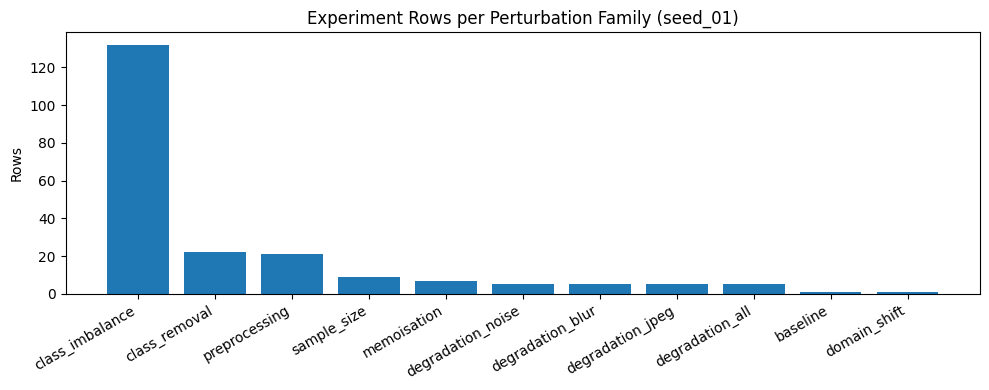

In [40]:
family_summary = summarize_by_family(df, BATCH_NAME)
#family_summary


In [41]:
df_delta, delta_summary = compute_baseline_deltas(df)
delta_summary


,fid_delta,kid_mean_delta,is_mean_delta,precision_delta,recall_delta,density_delta,coverage_delta
perturbation_family,,,,,,,
baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
class_imbalance,0.278167,0.000284,-0.169482,0.007801,-0.011624,0.035141,0.017264
class_removal,1.560383,0.001314,-0.220674,0.008381,-0.019567,0.040781,0.004865
degradation_all,223.816016,0.313050,-5.011535,-0.319688,-0.659375,-0.592469,-0.725313
degradation_blur,183.414047,0.200678,-4.769263,-0.420938,-0.634687,-0.693125,-0.713125
degradation_jpeg,83.440445,0.116973,-2.870256,-0.171875,-0.389844,-0.384563,-0.454688
degradation_noise,179.635356,0.202954,-4.153312,-0.375469,-0.582500,-0.754469,-0.697969
domain_shift,248.644819,0.241602,0.000000,-0.800000,-0.503125,-0.970938,-0.877344
memoisation,-6.213184,-0.002001,0.320587,0.036942,0.066406,0.010022,0.053348


,fid_delta,kid_mean_delta,is_mean_delta,precision_delta,recall_delta,density_delta,coverage_delta
perturbation_family,,,,,,,
baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
class_imbalance,0.278167,0.000284,-0.169482,0.007801,-0.011624,0.035141,0.017264
class_removal,1.560383,0.001314,-0.220674,0.008381,-0.019567,0.040781,0.004865
degradation_all,223.816016,0.313050,-5.011535,-0.319688,-0.659375,-0.592469,-0.725313
degradation_blur,183.414047,0.200678,-4.769263,-0.420938,-0.634687,-0.693125,-0.713125
degradation_jpeg,83.440445,0.116973,-2.870256,-0.171875,-0.389844,-0.384563,-0.454688
degradation_noise,179.635356,0.202954,-4.153312,-0.375469,-0.582500,-0.754469,-0.697969
domain_shift,248.644819,0.241602,0.000000,-0.800000,-0.503125,-0.970938,-0.877344
memoisation,-6.213184,-0.002001,0.320587,0.036942,0.066406,0.010022,0.053348


In [ ]:
#show_top_worst(df_delta)


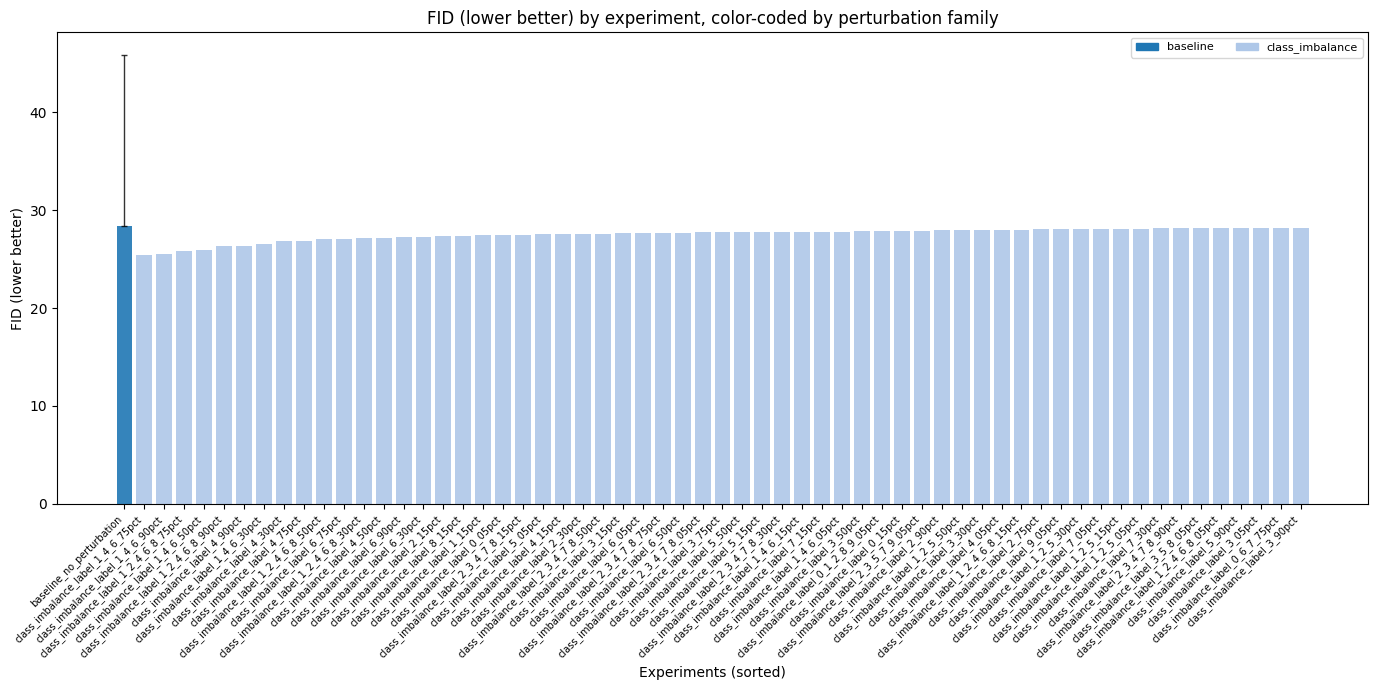

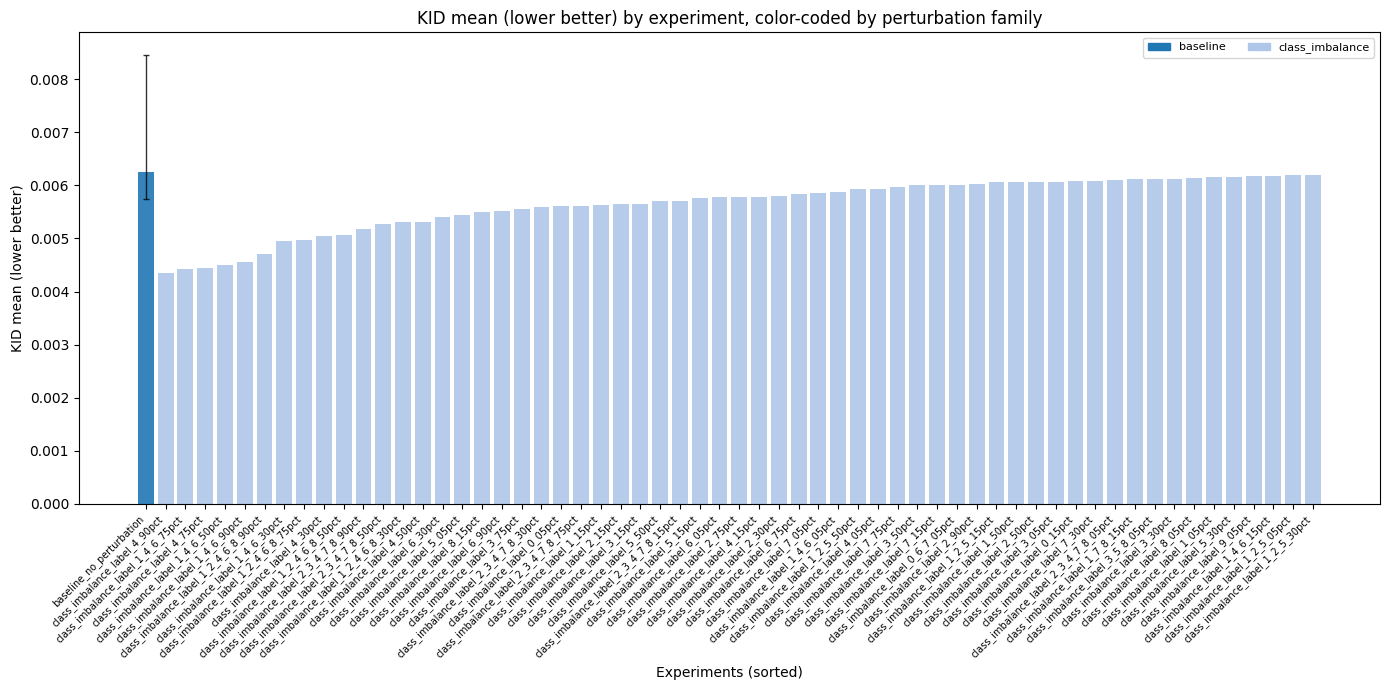

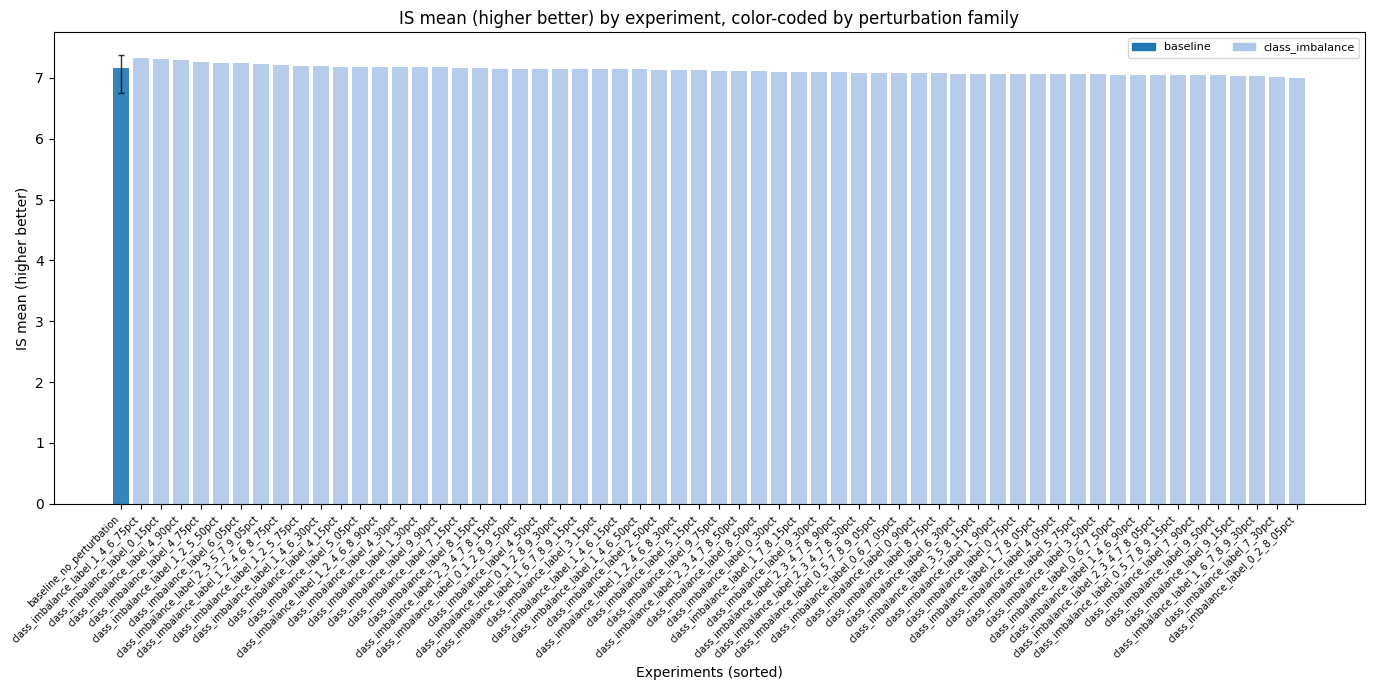

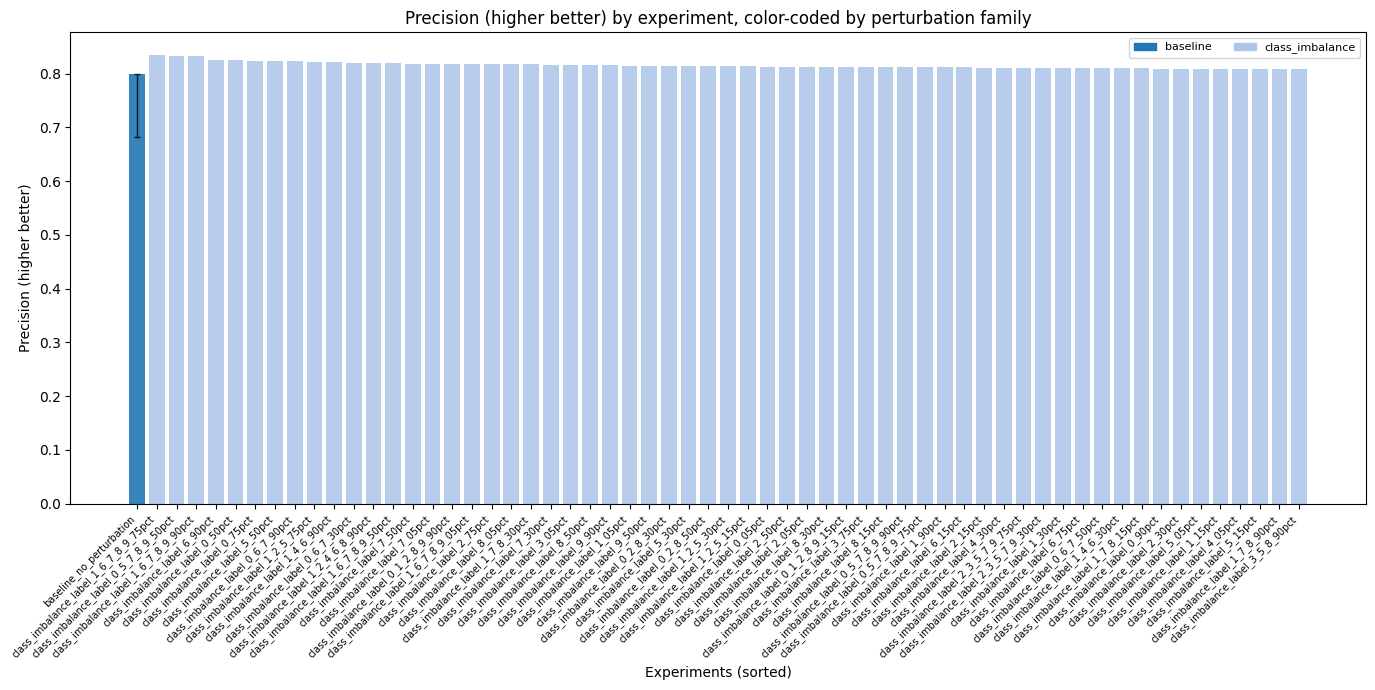

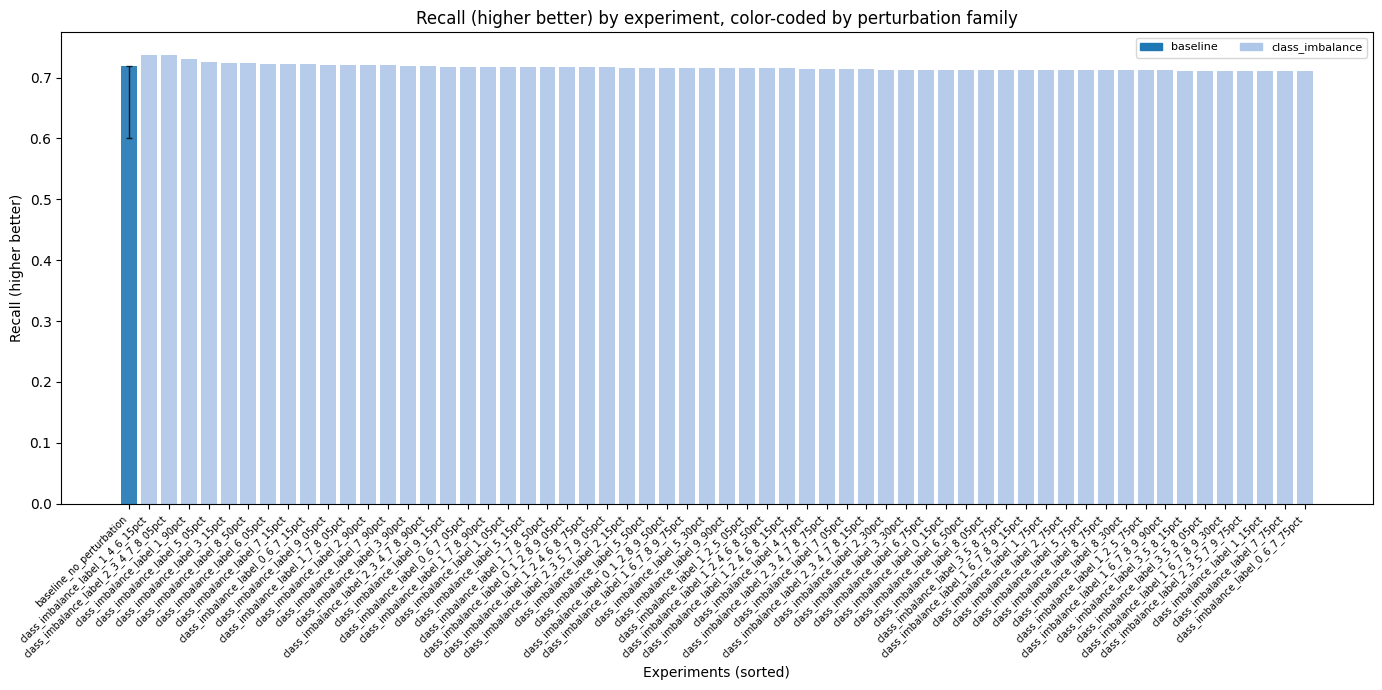

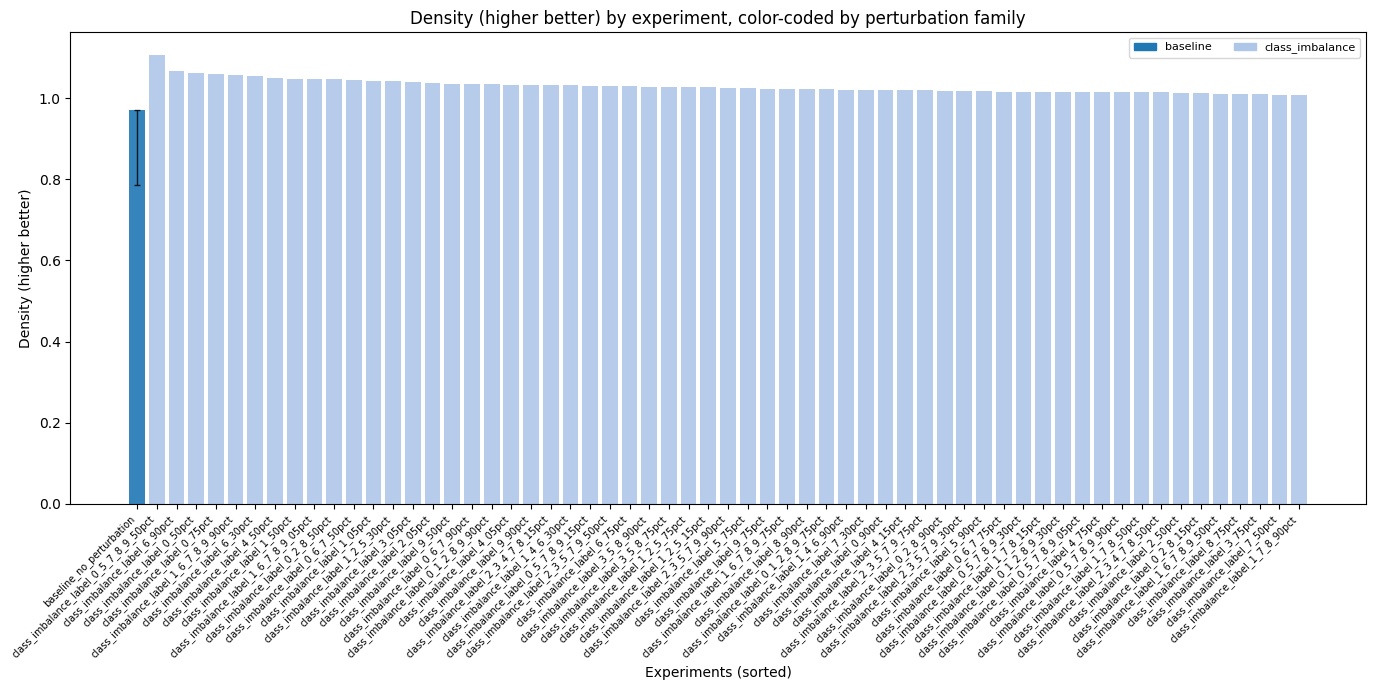

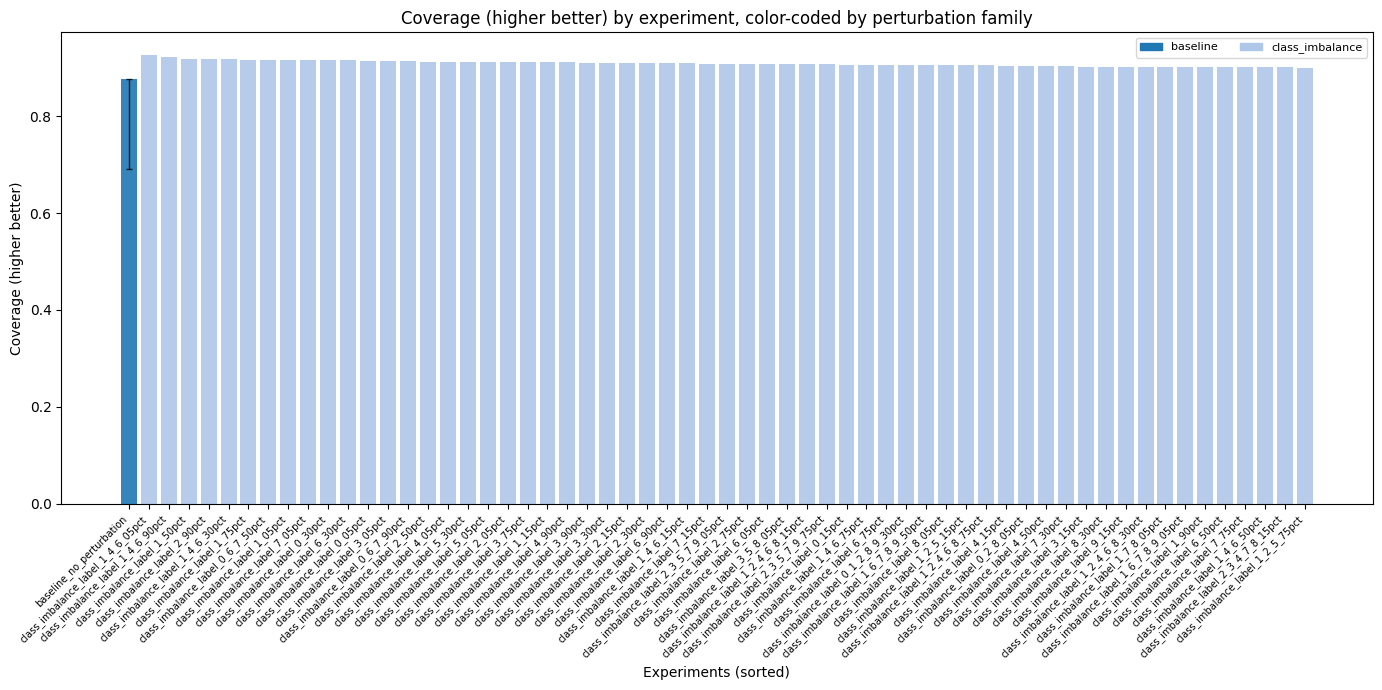

In [42]:
plot_metric_bars(df_delta)


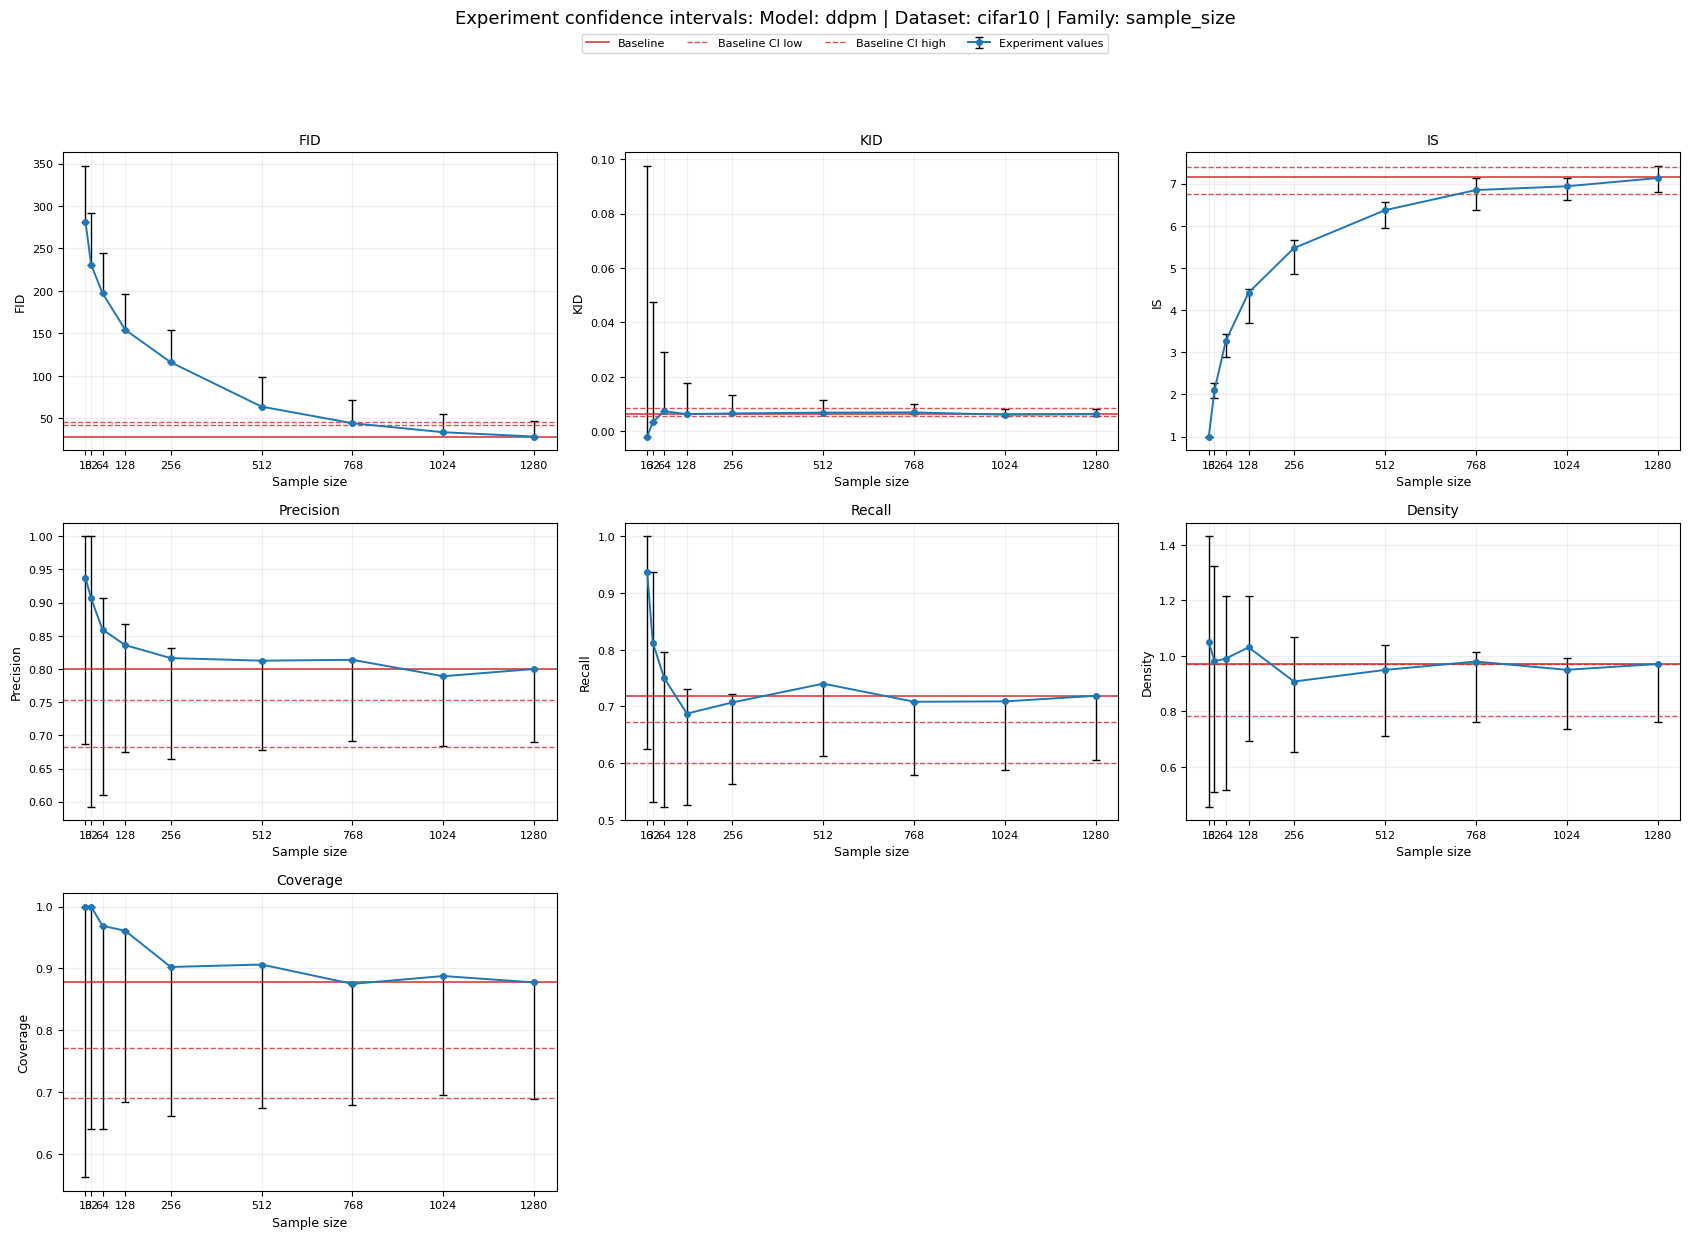

Plotted confidence intervals for 9 non-baseline experiment rows across 1 grouped plot set(s).


,report_file,experiment_id,name,model,dataset,status,exit_code,metrics_expected,metrics_available,step_name,...,recall_ci_high,density_ci_low,density_ci_high,coverage_ci_low,coverage_ci_high,fid_error,kid_error,is_error,pr_error,dc_error
182,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_16__63acad2b93,sample_size_16,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,1.000000,0.455937,1.431562,0.562500,1.000000,,,,,
183,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_32__0c0e31f35e,sample_size_32,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.937500,0.509219,1.322969,0.639844,1.000000,,,,,
184,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_64__067afb3bb8,sample_size_64,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.796875,0.515547,1.215937,0.640625,0.953125,,,,,
185,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_128__6ae1362290,sample_size_128,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.730664,0.693438,1.215937,0.683398,0.926367,,,,,
186,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_256__efeb4940ff,sample_size_256,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.722852,0.653828,1.068672,0.662012,0.837988,,,,,
187,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_512__6bc9946de0,sample_size_512,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.720068,0.711377,1.037998,0.674756,0.795117,,,,,
188,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_768__27b828a24d,sample_size_768,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.680371,0.762656,1.013203,0.679622,0.779329,,,,,
189,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_1024__d6c09ceeb1,sample_size_1024,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.662109,0.735054,0.992729,0.694800,0.784692,,,,,
190,seed_01_ddpm_cifar10_perturbation_tests.json,sample_size_1280__577d8a56d5,sample_size_1280,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.670098,0.761301,0.951336,0.688867,0.771660,,,,,


In [ ]:
# plot experiment-level confidence intervals for rows that expose bootstrap CIs
plot_experiment_confidence_intervals(df)


## Metric Scorecard Plot

Notebook version of `Scripts/metrics_performance.py` using the currently loaded `df`. It computes monotonicity (Spearman), sensitivity (max relative baseline change), robustness (CV across k-means variants), then renders the scorecard figure.


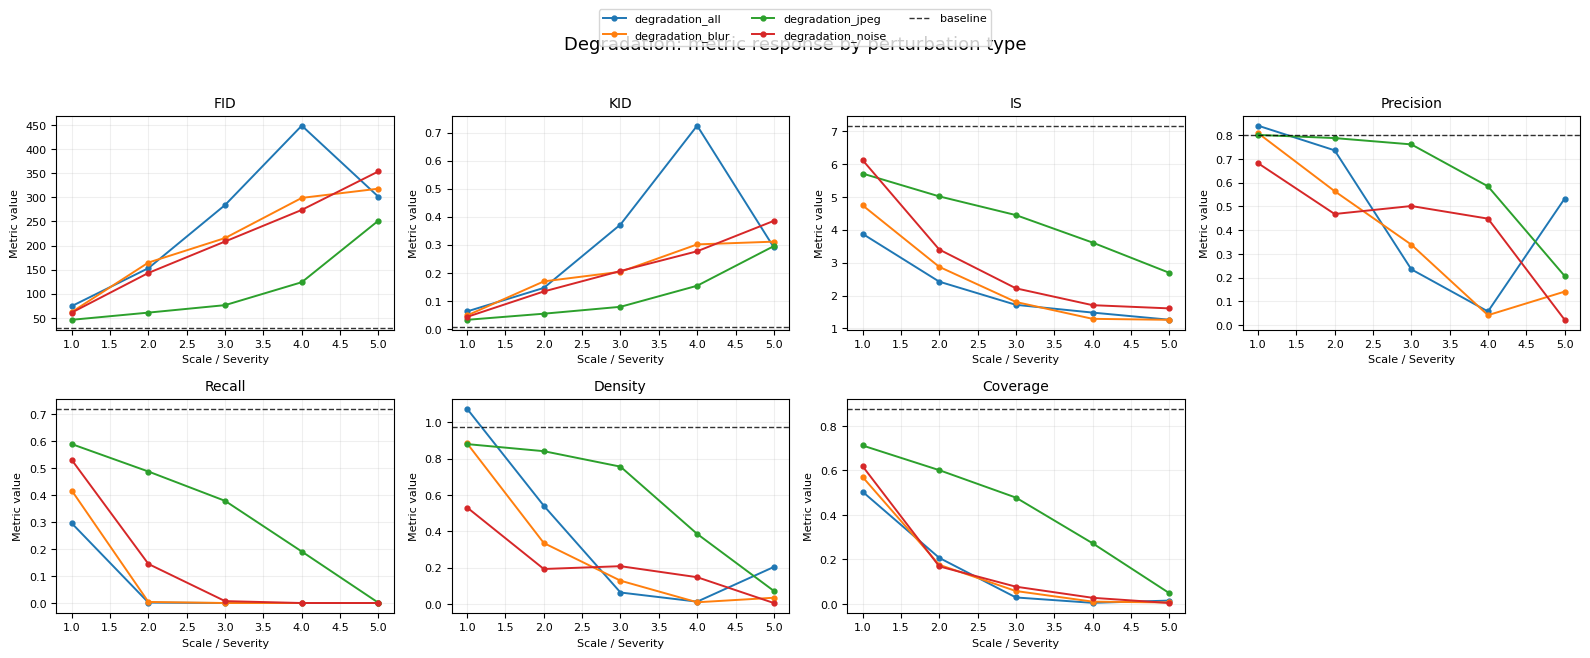

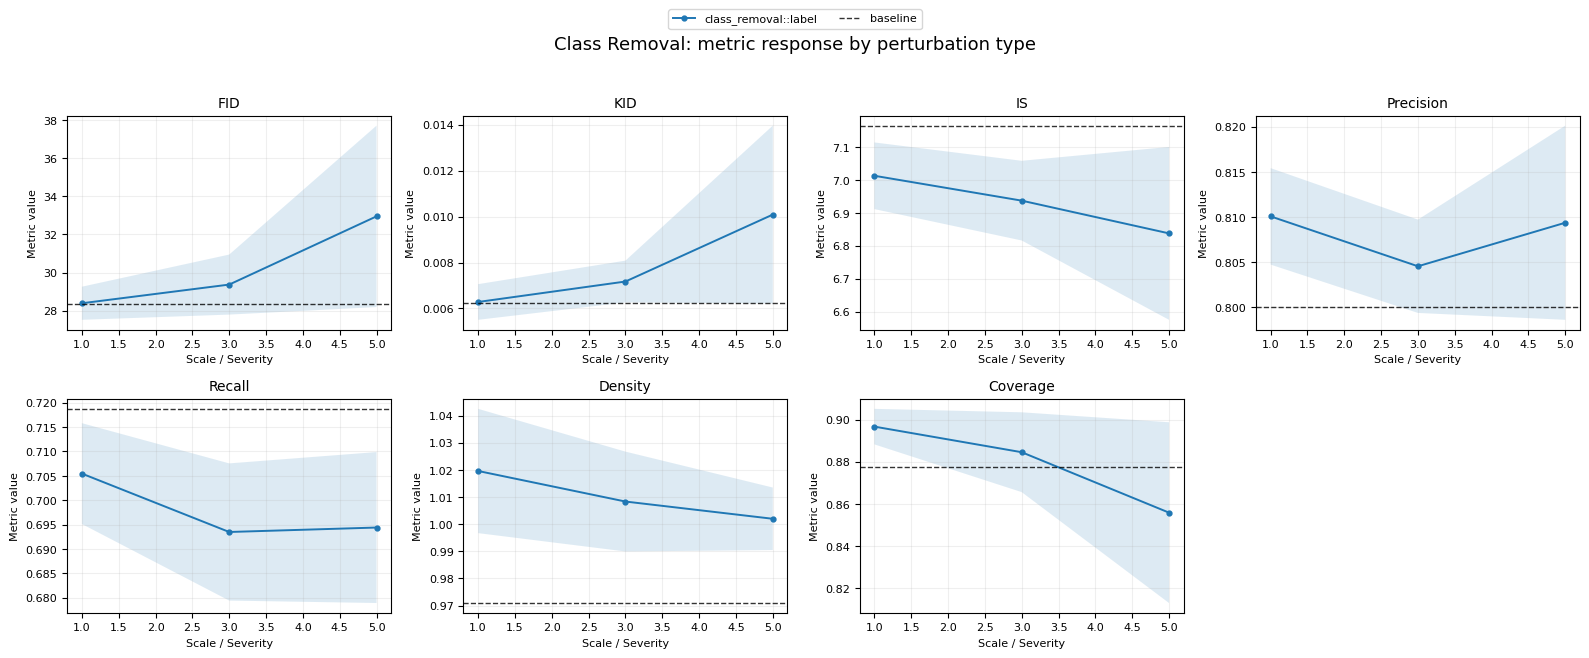

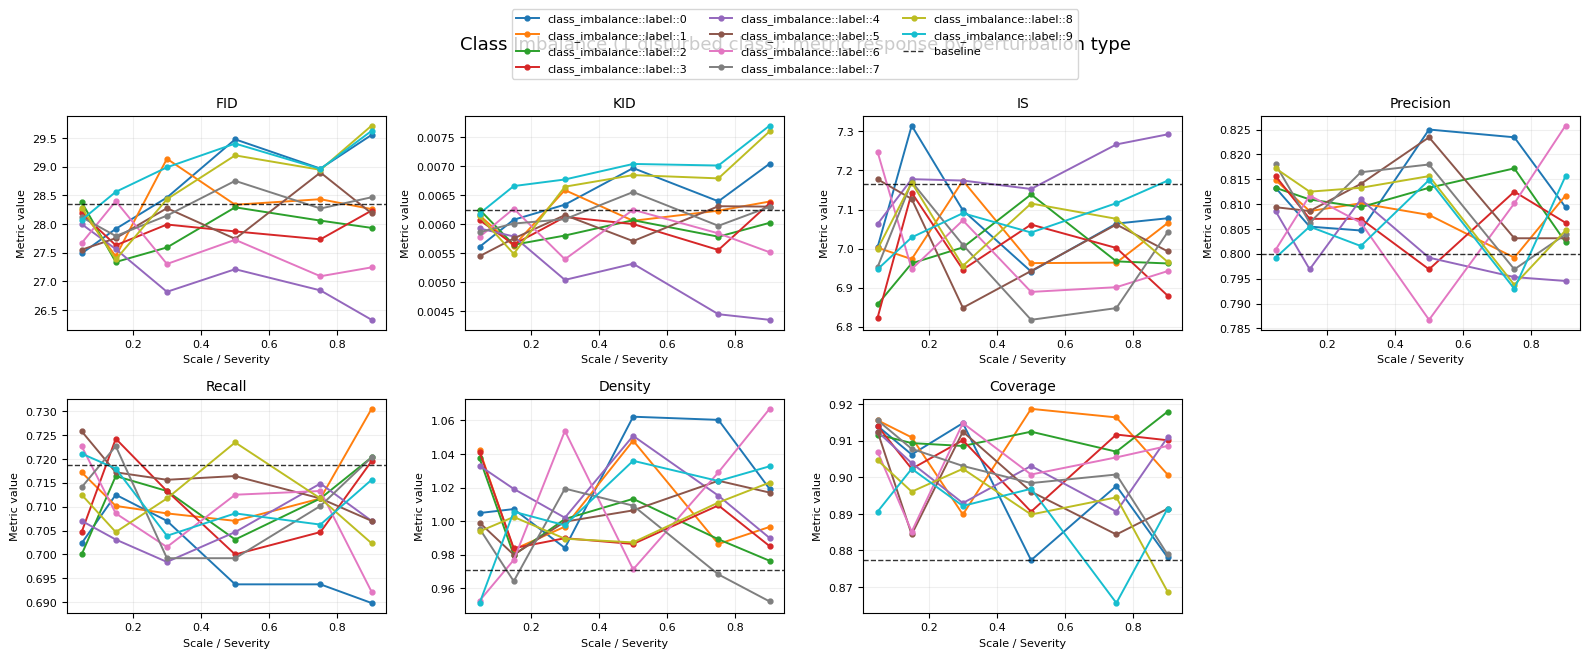

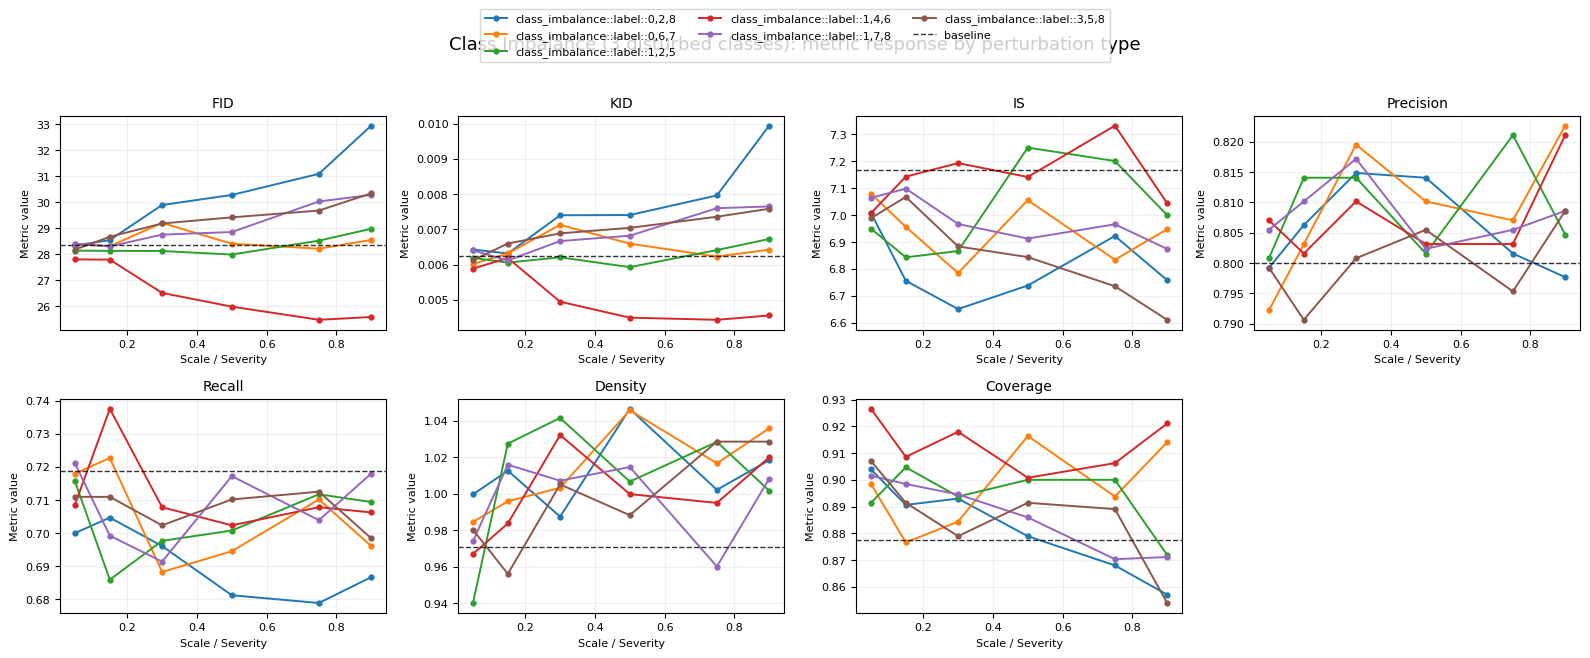

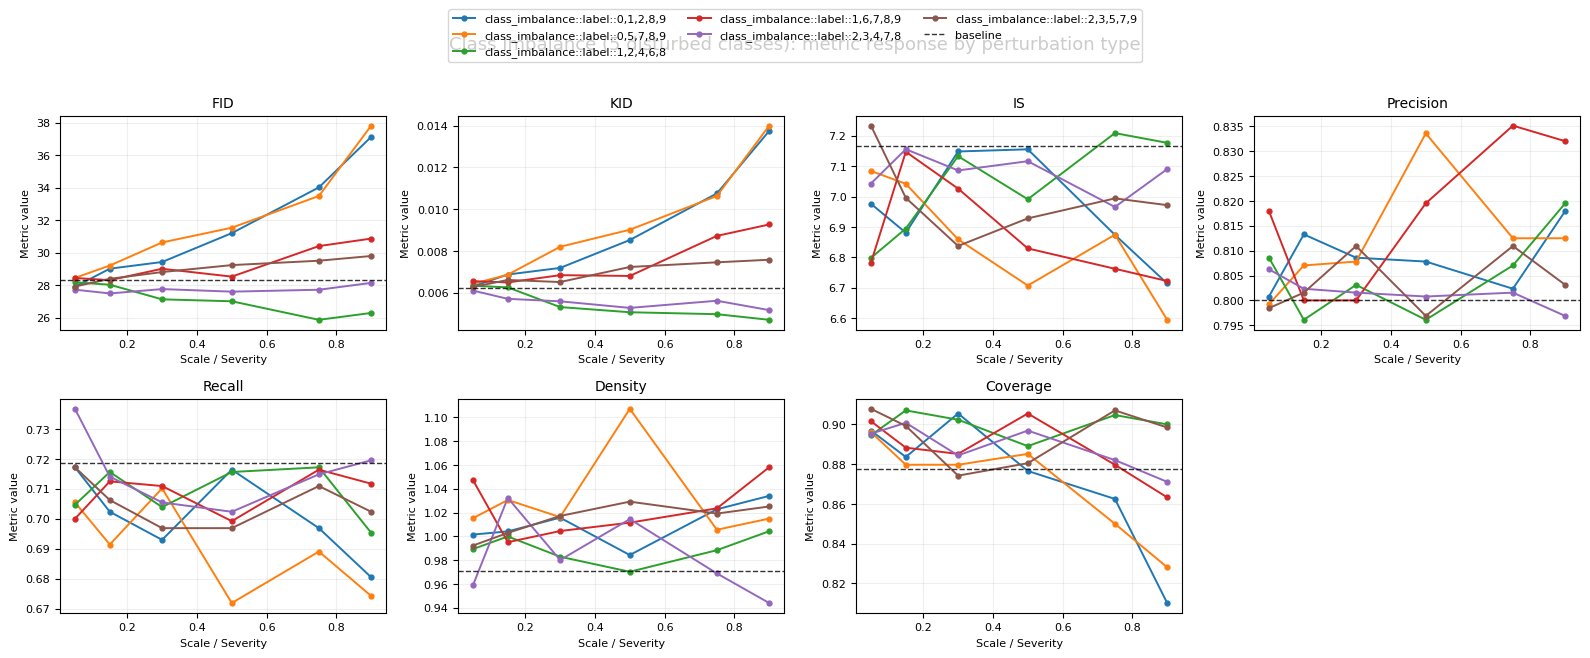

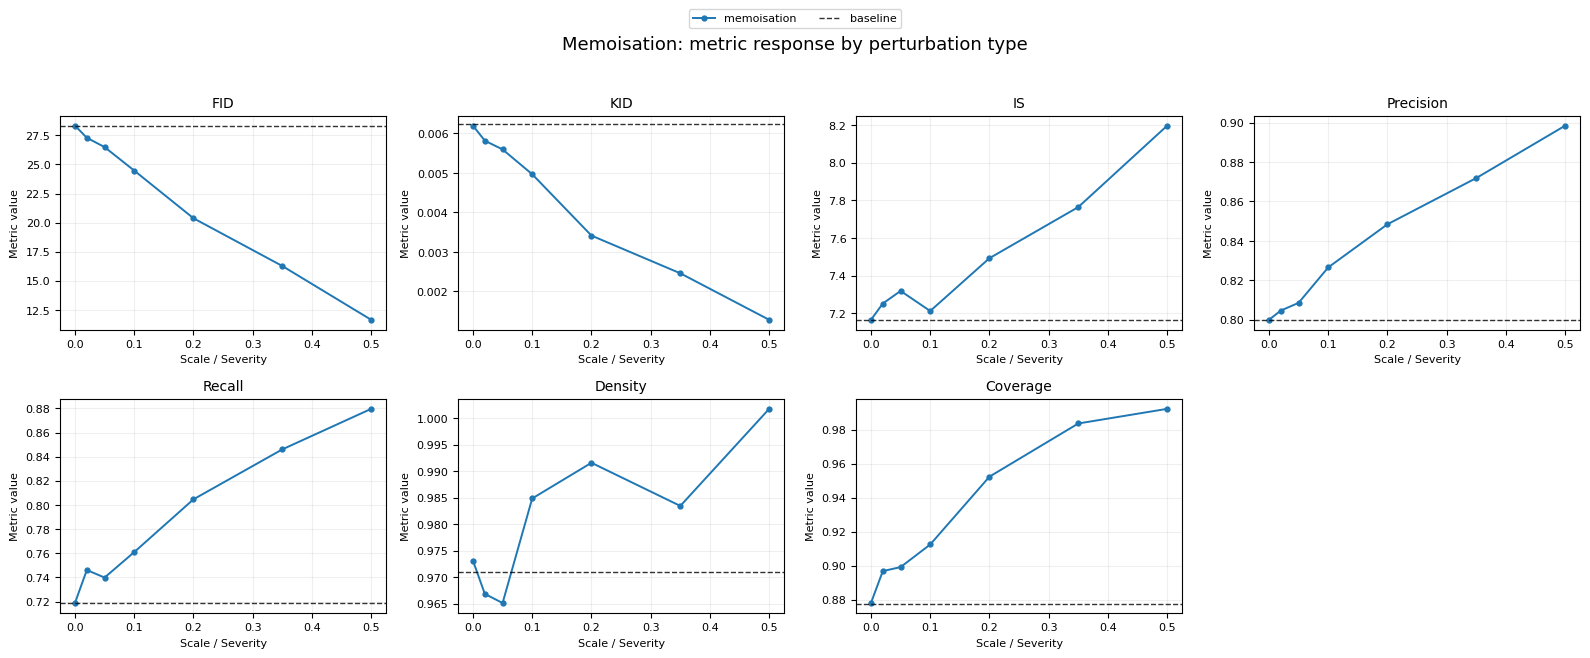

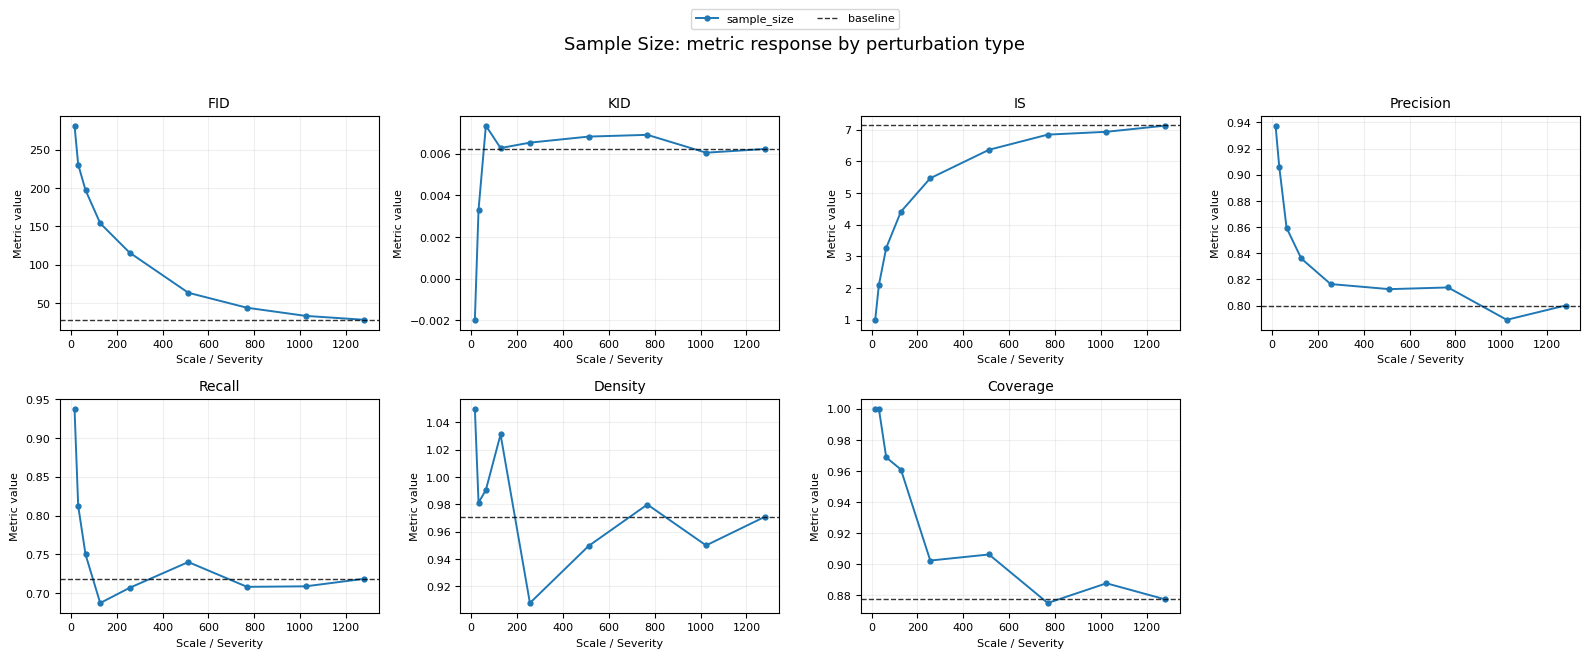

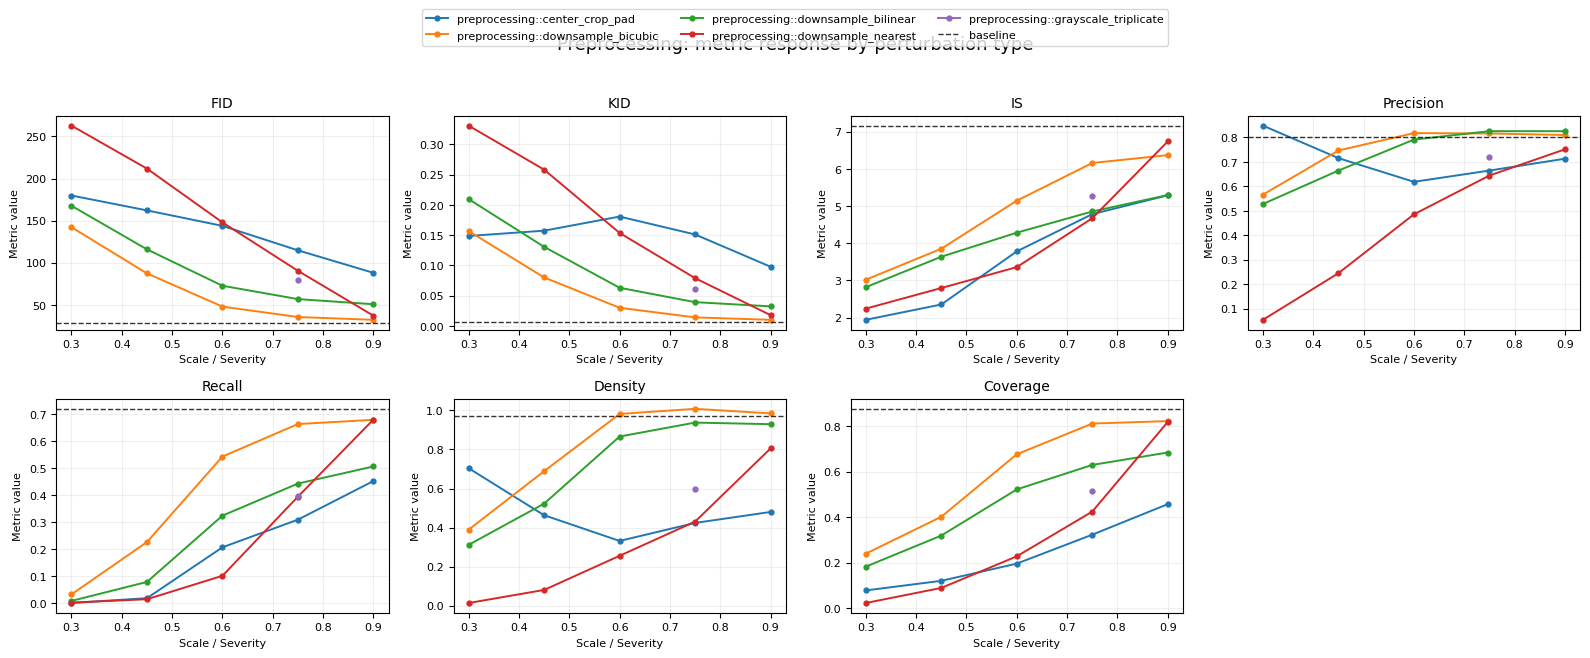

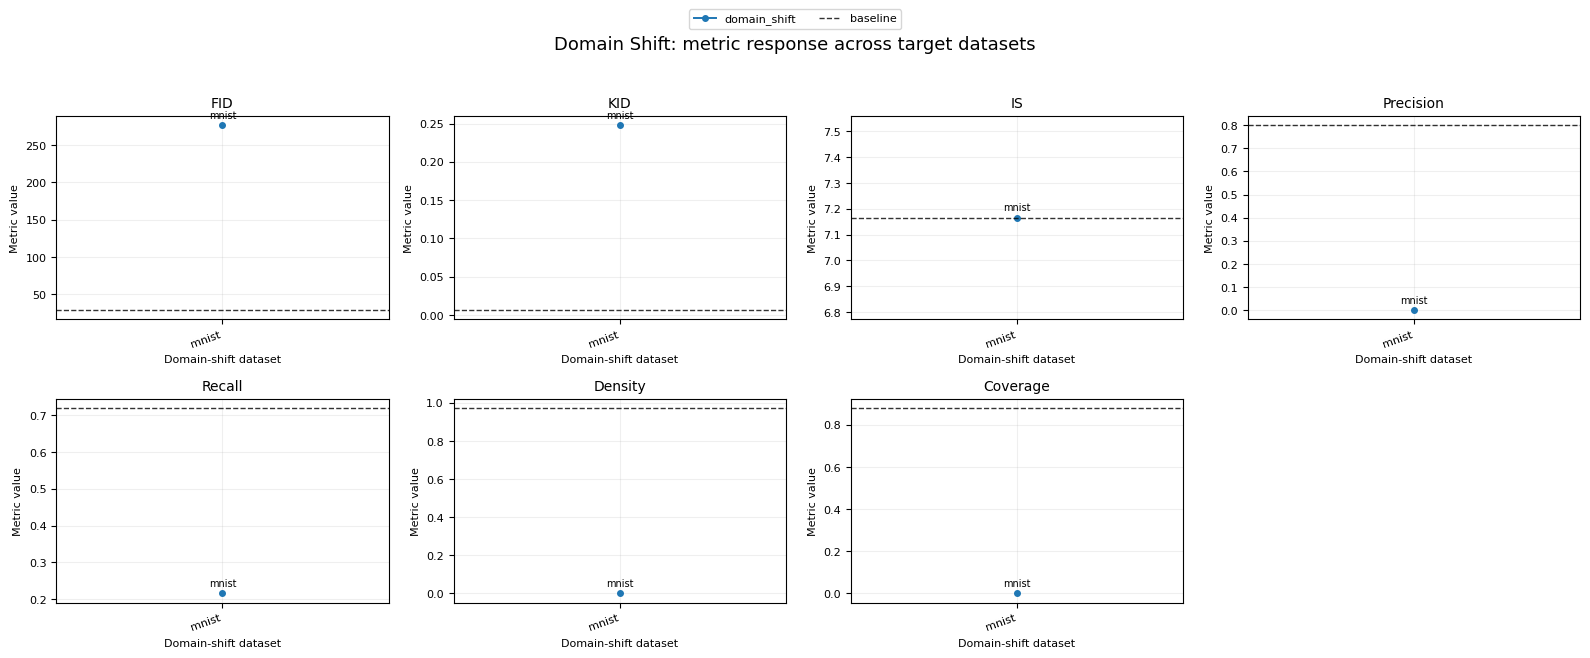

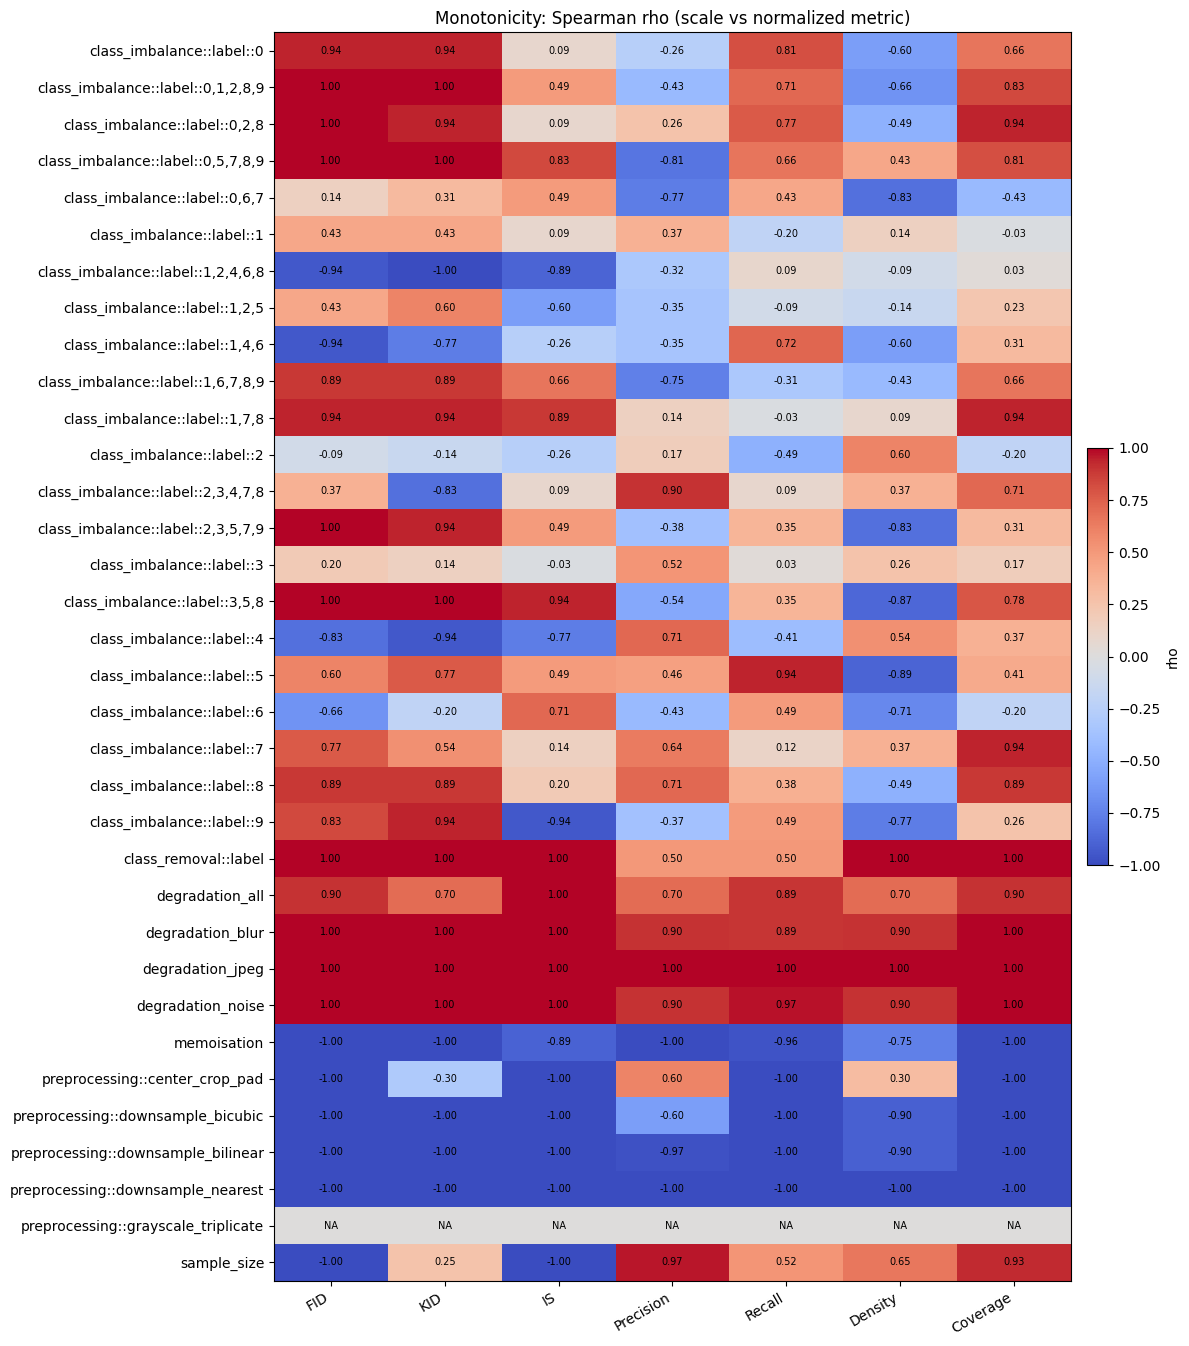

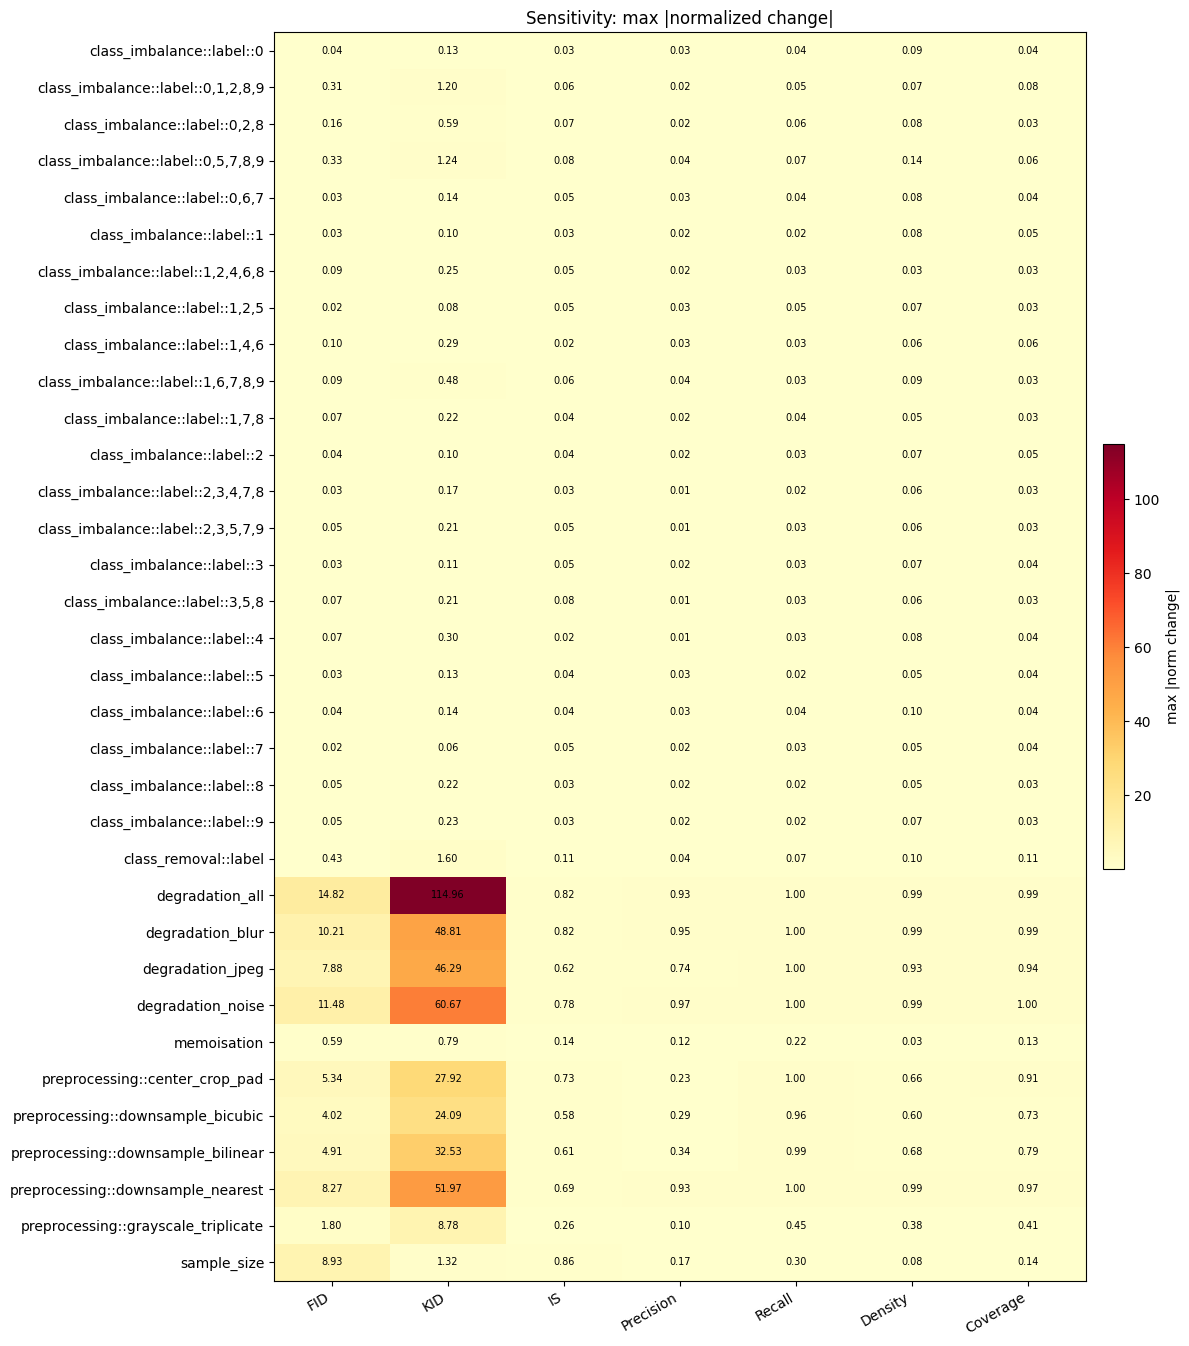

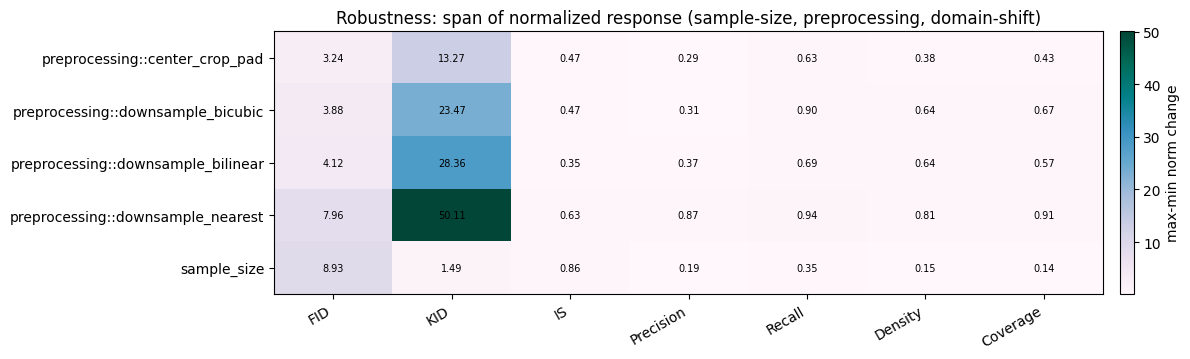

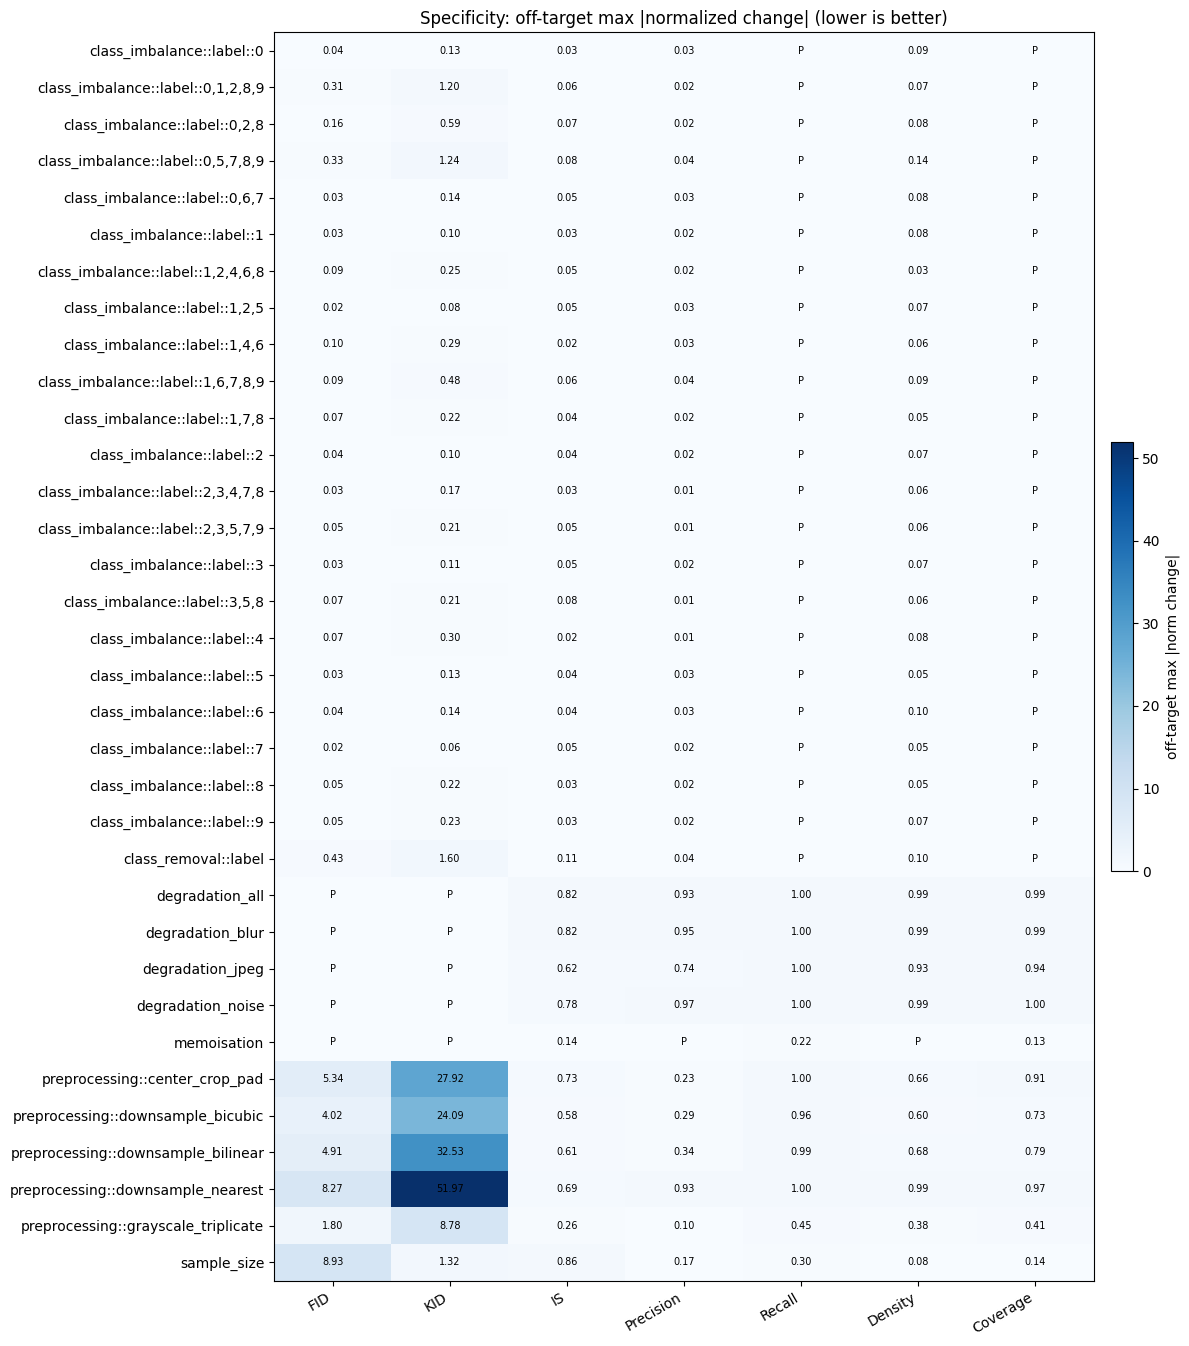

Perturbation groups included (curve analysis; domain_shift has dedicated plots):
['class_imbalance::label::0', 'class_imbalance::label::0,1,2,8,9', 'class_imbalance::label::0,2,8', 'class_imbalance::label::0,5,7,8,9', 'class_imbalance::label::0,6,7', 'class_imbalance::label::1', 'class_imbalance::label::1,2,4,6,8', 'class_imbalance::label::1,2,5', 'class_imbalance::label::1,4,6', 'class_imbalance::label::1,6,7,8,9', 'class_imbalance::label::1,7,8', 'class_imbalance::label::2', 'class_imbalance::label::2,3,4,7,8', 'class_imbalance::label::2,3,5,7,9', 'class_imbalance::label::3', 'class_imbalance::label::3,5,8', 'class_imbalance::label::4', 'class_imbalance::label::5', 'class_imbalance::label::6', 'class_imbalance::label::7', 'class_imbalance::label::8', 'class_imbalance::label::9', 'class_removal::label', 'degradation_all', 'degradation_blur', 'degradation_jpeg', 'degradation_noise', 'memoisation', 'preprocessing::center_crop_pad', 'preprocessing::downsample_bicubic', 'preprocessing::do

,specificity_kind,is_na,count
0,off_target,False,180
1,primary_metric,False,58


Monotonicity (head):


,perturbation_group,metric,rho_spearman,p_value,abs_rho
6,class_imbalance::label::0,coverage,0.657143,0.156175,0.657143
5,class_imbalance::label::0,density,-0.600000,0.208000,0.600000
0,class_imbalance::label::0,fid,0.942857,0.004805,0.942857
2,class_imbalance::label::0,is_mean,0.085714,0.871743,0.085714
1,class_imbalance::label::0,kid_mean,0.942857,0.004805,0.942857
3,class_imbalance::label::0,precision,-0.257143,0.622787,0.257143
4,class_imbalance::label::0,recall,0.811679,0.049858,0.811679
13,"class_imbalance::label::0,1,2,8,9",coverage,0.828571,0.041563,0.828571
12,"class_imbalance::label::0,1,2,8,9",density,-0.657143,0.156175,0.657143
7,"class_imbalance::label::0,1,2,8,9",fid,1.000000,0.000000,1.000000


Sensitivity (head):


,perturbation_group,metric,max_abs_norm_change,mean_abs_norm_change
6,class_imbalance::label::0,coverage,0.042743,0.023598
5,class_imbalance::label::0,density,0.093981,0.053589
0,class_imbalance::label::0,fid,0.042882,0.025776
2,class_imbalance::label::0,is_mean,0.031228,0.018384
1,class_imbalance::label::0,kid_mean,0.127174,0.068208
3,class_imbalance::label::0,precision,0.031250,0.016927
4,class_imbalance::label::0,recall,0.040217,0.026268
13,"class_imbalance::label::0,1,2,8,9",coverage,0.076581,0.025972
12,"class_imbalance::label::0,1,2,8,9",density,0.065014,0.040715
7,"class_imbalance::label::0,1,2,8,9",fid,0.309680,0.114731


Robustness (head):


,perturbation_group,metric,n_points,mean_norm,std_norm,cv_norm,span_norm
13,preprocessing::center_crop_pad,coverage,5,0.731968,0.158546,0.216602,0.432769
12,preprocessing::center_crop_pad,density,5,0.504892,0.126501,0.250551,0.383006
7,preprocessing::center_crop_pad,fid,5,3.858679,1.159795,0.300568,3.238377
9,preprocessing::center_crop_pad,is_mean,5,0.493619,0.183109,0.370953,0.467827
8,preprocessing::center_crop_pad,kid_mean,5,22.550230,4.344315,0.192651,13.268146
10,preprocessing::center_crop_pad,precision,5,0.109766,0.096094,0.875448,0.287109
11,preprocessing::center_crop_pad,recall,5,0.726087,0.239532,0.329895,0.628261
20,preprocessing::downsample_bicubic,coverage,5,0.326269,0.264595,0.810972,0.665183
19,preprocessing::downsample_bicubic,density,5,0.165465,0.248140,1.499655,0.636466
14,preprocessing::downsample_bicubic,fid,5,1.436843,1.463530,1.018573,3.878286


Specificity (head):


,perturbation_group,metric,off_target_max_abs_norm,off_target_mean_abs_norm,specificity_kind
6,class_imbalance::label::0,coverage,0.000000,0.000000,primary_metric
5,class_imbalance::label::0,density,0.093981,0.053589,off_target
0,class_imbalance::label::0,fid,0.042882,0.025776,off_target
2,class_imbalance::label::0,is_mean,0.031228,0.018384,off_target
1,class_imbalance::label::0,kid_mean,0.127174,0.068208,off_target
3,class_imbalance::label::0,precision,0.031250,0.016927,off_target
4,class_imbalance::label::0,recall,0.000000,0.000000,primary_metric
13,"class_imbalance::label::0,1,2,8,9",coverage,0.000000,0.000000,primary_metric
12,"class_imbalance::label::0,1,2,8,9",density,0.065014,0.040715,off_target
7,"class_imbalance::label::0,1,2,8,9",fid,0.309680,0.114731,off_target


In [44]:
run_full_perturbation_analysis(df)
